# 🔍 Exploratory Data Analysis (EDA) — Used Car Price Prediction

**Target Variable:** `listed_price`

This notebook walks through a **beginner-friendly EDA** to understand our data and gain insights that will help build a better prediction model.

### What we'll cover:
1. **Setup & Data Loading**
2. **Target Variable Analysis** — Understanding `listed_price`
3. **Numerical Features Analysis** — Distributions & outliers
4. **Categorical Features Analysis** — Value counts & price patterns
5. **Feature vs Target Relationships** — What drives car price?
6. **Correlation Analysis** — Which features are most related to price?
7. **Key Insights & Takeaways**

---
## 1. Setup & Data Loading

In [1]:
# ── Import Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Plot Settings ──
# These settings make our charts look clean and professional
sns.set_style('whitegrid')                          # Clean white background with grid
plt.rcParams['figure.figsize'] = (12, 6)            # Default chart size
plt.rcParams['font.size'] = 12                      # Readable font size
plt.rcParams['axes.titlesize'] = 14                 # Title size
plt.rcParams['axes.labelsize'] = 12                 # Axis label size

# A nice color palette for our plots
COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#16a085', '#c0392b']
sns.set_palette(COLORS)

# ── Display Settings ──
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ── Load Dataset ──
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('eda.ipynb'))
CSV_PATH = os.path.join(NOTEBOOK_DIR, 'cars_data_clean.csv')

if not os.path.exists(CSV_PATH):
    CSV_PATH = r'd:\MLPs\Used Car Price Prediction & Valuation System\cars_data_clean.csv'

df = pd.read_csv(CSV_PATH)

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

✅ Dataset loaded: 37,813 rows × 66 columns
   Memory usage: 131.4 MB


In [3]:
# Quick look at the data
df.head(3)

,usedCarSkuId,loc,myear,body,transmission,fuel,km,ip,images,imgCount,threesixty,dvn,oem,model,variant,City,listed_price,discountValue,utype,carType,top_features,comfort_features,interior_features,exterior_features,safety_features,Color,Engine Type,No of Cylinder,Valves per Cylinder,Valve Configuration,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Seats,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,Doors,Cargo Volume,model_type_new,state,exterior_color,owner_type,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,Bore,Stroke
0,7111bf25-97af-47f9-867b-40879190d800,gomti nagar,2016,hatchback,manual,cng,"69,162.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,maruti wagon r lxi cng,maruti,maruti wagon r,lxi cng,lucknow,"370,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'rem...","['air conditioner', 'heater', 'digital odomete...","['adjustable head lights', 'manually adjustabl...","['centeral locking', 'child safety locks', 'da...",silver,k10b engine,3.00,4.00,dohc,False,False,"3,599.00","1,495.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,350.00",5 speed,fwd,5.00,power,4.60,ventilated disc,drum,137.00,15.90,tubeless,5.00,180.00,used,uttar pradesh,silver,first,NaN,NaN,NaN,NaN,58.16,"6,200.00",77.00,"3,500.00",69.00,NaN
1,c309efc1-efaf-4f82-81ad-dcb38eb36665,borivali west,2015,hatchback,manual,cng,"45,864.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,maruti celerio green vxi,maruti,maruti celerio,green vxi,mumbai,"365,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'pow...","['air conditioner', 'heater', 'digital odomete...","['adjustable head lights', 'manually adjustabl...","['centeral locking', 'child safety locks', 'da...",grey,k10b engine,3.00,4.00,dohc,False,False,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,350.00",5 speed,fwd,5.00,power,4.70,ventilated disc,drum,150.00,15.05,tubeless radial,5.00,235.00,used,maharashtra,grey,first,Gasoline Port Injection,11.00,NaN,NaN,58.20,"6,000.00",78.00,"3,500.00",73.00,NaN
2,7609f710-0c97-4f00-9a47-9b9284b62d3a,jasola,2015,sedan,manual,cng,"81,506.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,honda amaze s plus i-vtec,honda,honda amaze,s plus i-vtec,new delhi,"421,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'pow...","['air conditioner', 'heater', 'adjustable stee...","['adjustable head lights', 'power adjustable e...","['centeral locking', 'power door locks', 'chil...",silver,i-vtec petrol engine,4.00,4.00,sohc,False,False,"3,990.00","1,680.00","1,505.00","2,405.00",NaN,NaN,950.00,NaN,5 speed,fwd,5.00,power,4.50,disc,drum,160.00,15.00,tubeless radial,4.00,400.00,used,delhi,silver,second,NaN,NaN,NaN,NaN,86.70,"6,000.00",109.00,"4,500.00",NaN,NaN


In [4]:
# ── Separate columns by type for easier analysis ──
#
# We pick the most meaningful columns for EDA.
# Some columns like 'usedCarSkuId', 'images', feature lists, etc.
# are identifiers or complex text — not useful for basic EDA.

# Key numerical columns (things we can measure with numbers)
num_cols = ['listed_price', 'km', 'myear', 'imgCount', 'discountValue',
            'Length', 'Width', 'Height', 'Wheel Base', 'Kerb Weight', 'Gross Weight',
            'Seats', 'Turning Radius', 'Top Speed', 'Acceleration', 'Doors',
            'Cargo Volume', 'No of Cylinder', 'Valves per Cylinder',
            'Max Power Delivered', 'Max Power At', 'Max Torque Delivered', 'Max Torque At',
            'Ground Clearance Unladen', 'Compression Ratio', 'Alloy Wheel Size',
            'Bore', 'Stroke']

# Key categorical columns (things that fall into groups/categories)
cat_cols = ['body', 'transmission', 'fuel', 'oem', 'model', 'City',
            'utype', 'carType', 'Color', 'Gear Box', 'Drive Type',
            'Steering Type', 'Front Brake Type', 'Rear Brake Type',
            'Tyre Type', 'Valve Configuration', 'Turbo Charger', 'Super Charger',
            'model_type_new', 'state', 'exterior_color', 'owner_type',
            'Fuel Suppy System']

# Filter to columns that actually exist in the dataset
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

print(f'📊 Numerical columns selected: {len(num_cols)}')
print(f'🏷️  Categorical columns selected: {len(cat_cols)}')

📊 Numerical columns selected: 28
🏷️  Categorical columns selected: 23


---
## 2. Target Variable Analysis — `listed_price` 🎯

Before looking at anything else, let's deeply understand our **target variable** — the price we want to predict.

In [5]:
# ── Basic stats of listed_price ──
target = df['listed_price']

print('💰 LISTED PRICE — Key Statistics')
print('=' * 50)
print(f'Count        : {target.count():,}')
print(f'Mean (Avg)   : ₹{target.mean():,.0f}')
print(f'Median (50%) : ₹{target.median():,.0f}')
print(f'Std Deviation: ₹{target.std():,.0f}')
print(f'Minimum      : ₹{target.min():,.0f}')
print(f'Maximum      : ₹{target.max():,.0f}')
print(f'25th Percentile (Q1): ₹{target.quantile(0.25):,.0f}')
print(f'75th Percentile (Q3): ₹{target.quantile(0.75):,.0f}')
print('=' * 50)

# Skewness tells us if data is symmetric or lopsided
# Skewness > 0 means a long right tail (most cars are cheap, few are very expensive)
print(f'\nSkewness     : {target.skew():.2f}  → {"Right-skewed (positive)" if target.skew() > 0 else "Left-skewed (negative)"}')
print(f'Kurtosis     : {target.kurtosis():.2f}  → {"Heavy tails (many outliers)" if target.kurtosis() > 3 else "Normal-like tails"}')

💰 LISTED PRICE — Key Statistics
Count        : 37,813
Mean (Avg)   : ₹799,987
Median (50%) : ₹525,000
Std Deviation: ₹3,043,045
Minimum      : ₹11,963
Maximum      : ₹550,000,555
25th Percentile (Q1): ₹320,000
75th Percentile (Q3): ₹855,272

Skewness     : 156.62  → Right-skewed (positive)
Kurtosis     : 28087.13  → Heavy tails (many outliers)


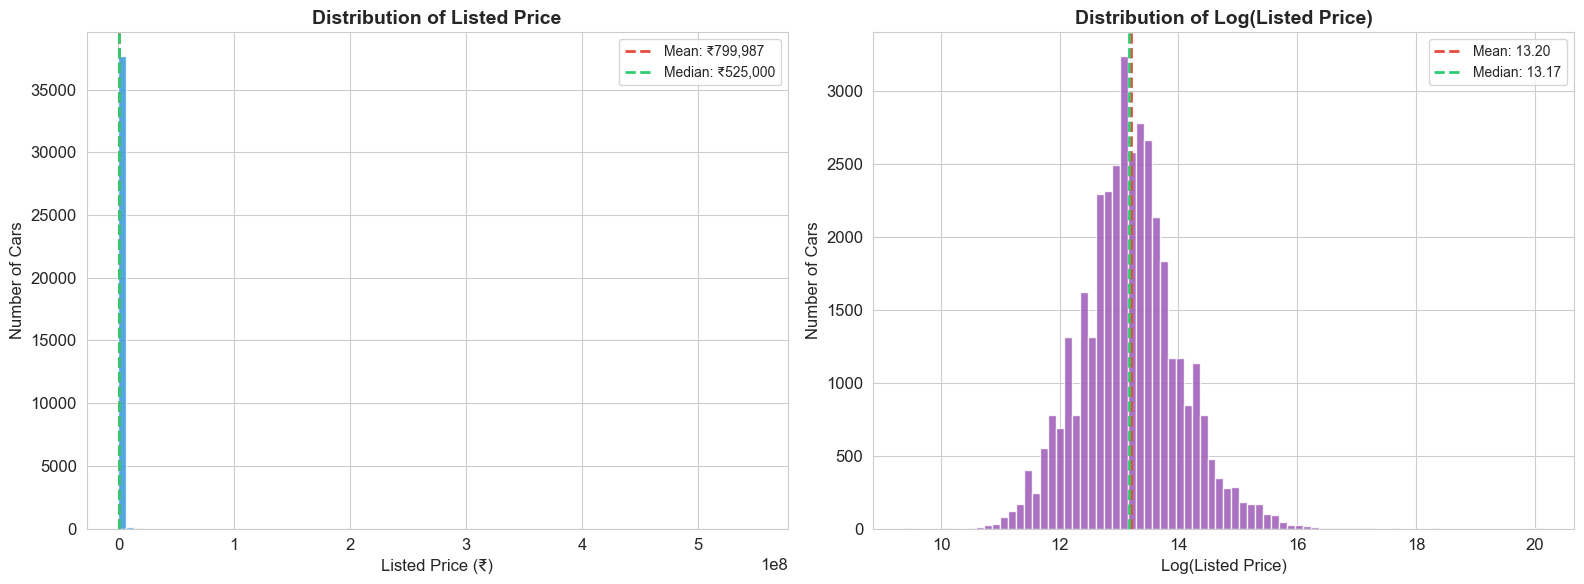

💡 Insight: The raw price is heavily right-skewed — most cars are budget/mid-range.
   The log-transformed price looks more bell-shaped (normal), which is better for ML models.


In [6]:
# ── Distribution of listed_price ──
#
# A histogram shows how prices are spread out.
# We plot both the raw price and log-transformed price.
# Log transform is useful when data is heavily skewed.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw price distribution
axes[0].hist(target, bins=80, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(target.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: ₹{target.mean():,.0f}')
axes[0].axvline(target.median(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Median: ₹{target.median():,.0f}')
axes[0].set_title('Distribution of Listed Price', fontweight='bold')
axes[0].set_xlabel('Listed Price (₹)')
axes[0].set_ylabel('Number of Cars')
axes[0].legend(fontsize=10)

# Plot 2: Log-transformed price distribution
log_price = np.log1p(target)   # log1p = log(1 + x), handles zero values safely
axes[1].hist(log_price, bins=80, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(log_price.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {log_price.mean():.2f}')
axes[1].axvline(log_price.median(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Median: {log_price.median():.2f}')
axes[1].set_title('Distribution of Log(Listed Price)', fontweight='bold')
axes[1].set_xlabel('Log(Listed Price)')
axes[1].set_ylabel('Number of Cars')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('💡 Insight: The raw price is heavily right-skewed — most cars are budget/mid-range.')
print('   The log-transformed price looks more bell-shaped (normal), which is better for ML models.')

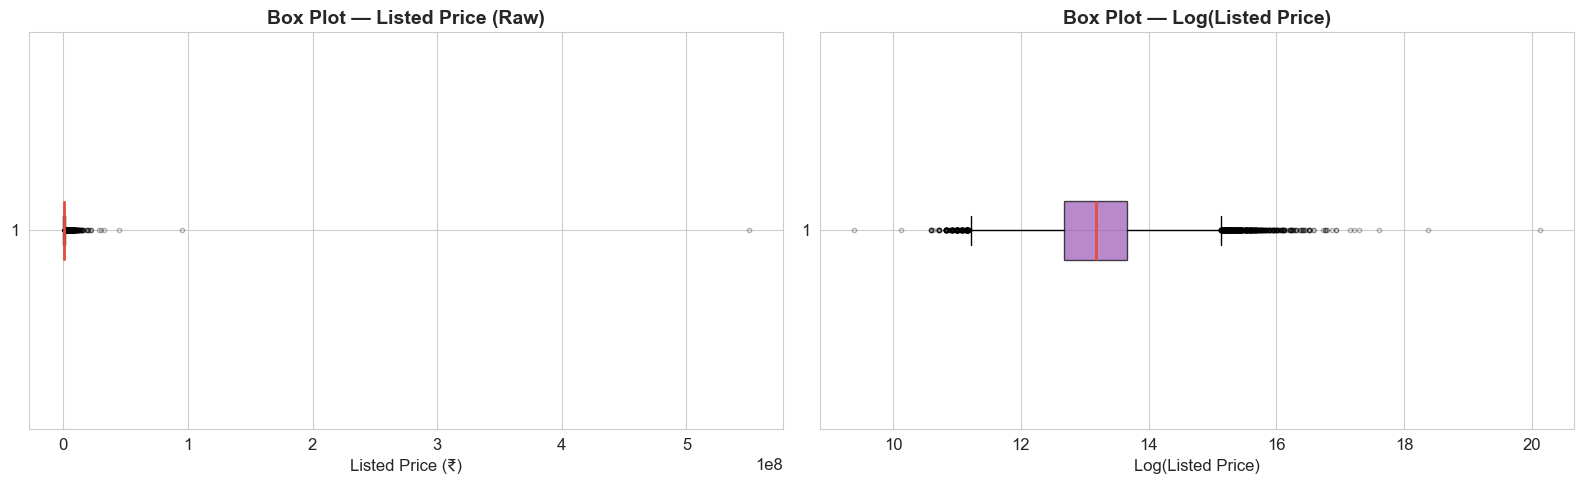

📦 IQR Method Outlier Detection:
   Q1 = ₹320,000  |  Q3 = ₹855,272  |  IQR = ₹535,272
   Lower Bound = ₹-482,908  |  Upper Bound = ₹1,658,180
   Outliers found: 3,249 (8.6% of data)


In [7]:
# ── Box plot of listed_price ──
#
# A box plot shows the spread and highlights outliers (dots beyond the whiskers).

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot(target.dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='#e74c3c', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title('Box Plot — Listed Price (Raw)', fontweight='bold')
axes[0].set_xlabel('Listed Price (₹)')

axes[1].boxplot(log_price.dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#9b59b6', alpha=0.7),
                medianprops=dict(color='#e74c3c', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('Box Plot — Log(Listed Price)', fontweight='bold')
axes[1].set_xlabel('Log(Listed Price)')

plt.tight_layout()
plt.show()

# Count outliers using the IQR method
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = target[(target < lower_bound) | (target > upper_bound)]

print(f'📦 IQR Method Outlier Detection:')
print(f'   Q1 = ₹{Q1:,.0f}  |  Q3 = ₹{Q3:,.0f}  |  IQR = ₹{IQR:,.0f}')
print(f'   Lower Bound = ₹{lower_bound:,.0f}  |  Upper Bound = ₹{upper_bound:,.0f}')
print(f'   Outliers found: {len(outliers):,} ({len(outliers)/len(target)*100:.1f}% of data)')

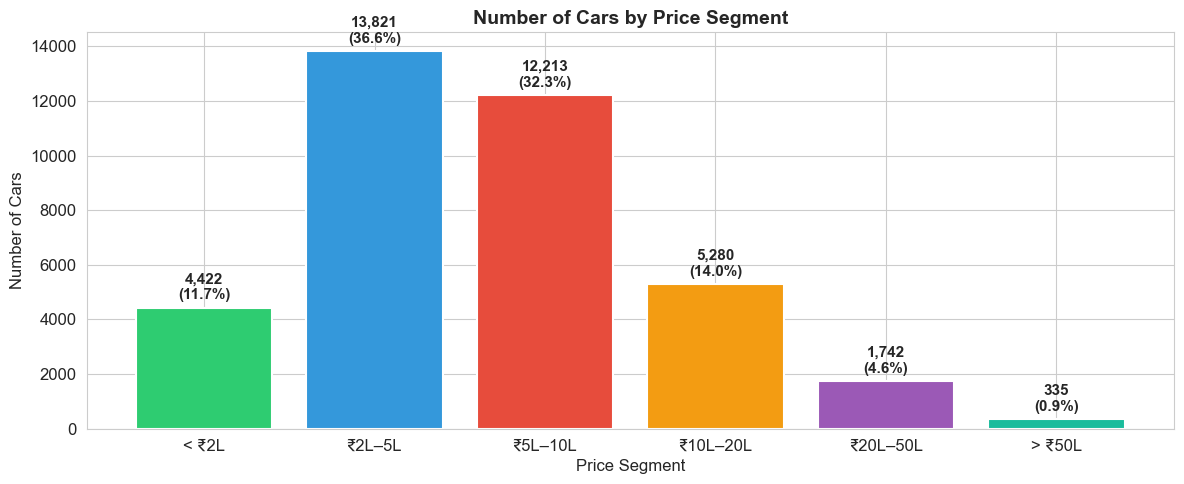

💡 Insight: This shows us which price segments dominate the dataset.


In [8]:
# ── Price Segments ──
#
# Let's see how many cars fall into different price brackets.

bins = [0, 200000, 500000, 1000000, 2000000, 5000000, float('inf')]
labels = ['< ₹2L', '₹2L–5L', '₹5L–10L', '₹10L–20L', '₹20L–50L', '> ₹50L']
df['price_segment'] = pd.cut(target, bins=bins, labels=labels)

segment_counts = df['price_segment'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(segment_counts.index, segment_counts.values, color=COLORS[:len(labels)], edgecolor='white', linewidth=1.5)

# Add count labels on each bar
for bar, count in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Number of Cars by Price Segment', fontweight='bold', fontsize=14)
ax.set_xlabel('Price Segment')
ax.set_ylabel('Number of Cars')
plt.tight_layout()
plt.show()

print('💡 Insight: This shows us which price segments dominate the dataset.')

---
## 3. Numerical Features Analysis 🔢

Let's look at the distribution and spread of our key numerical features.

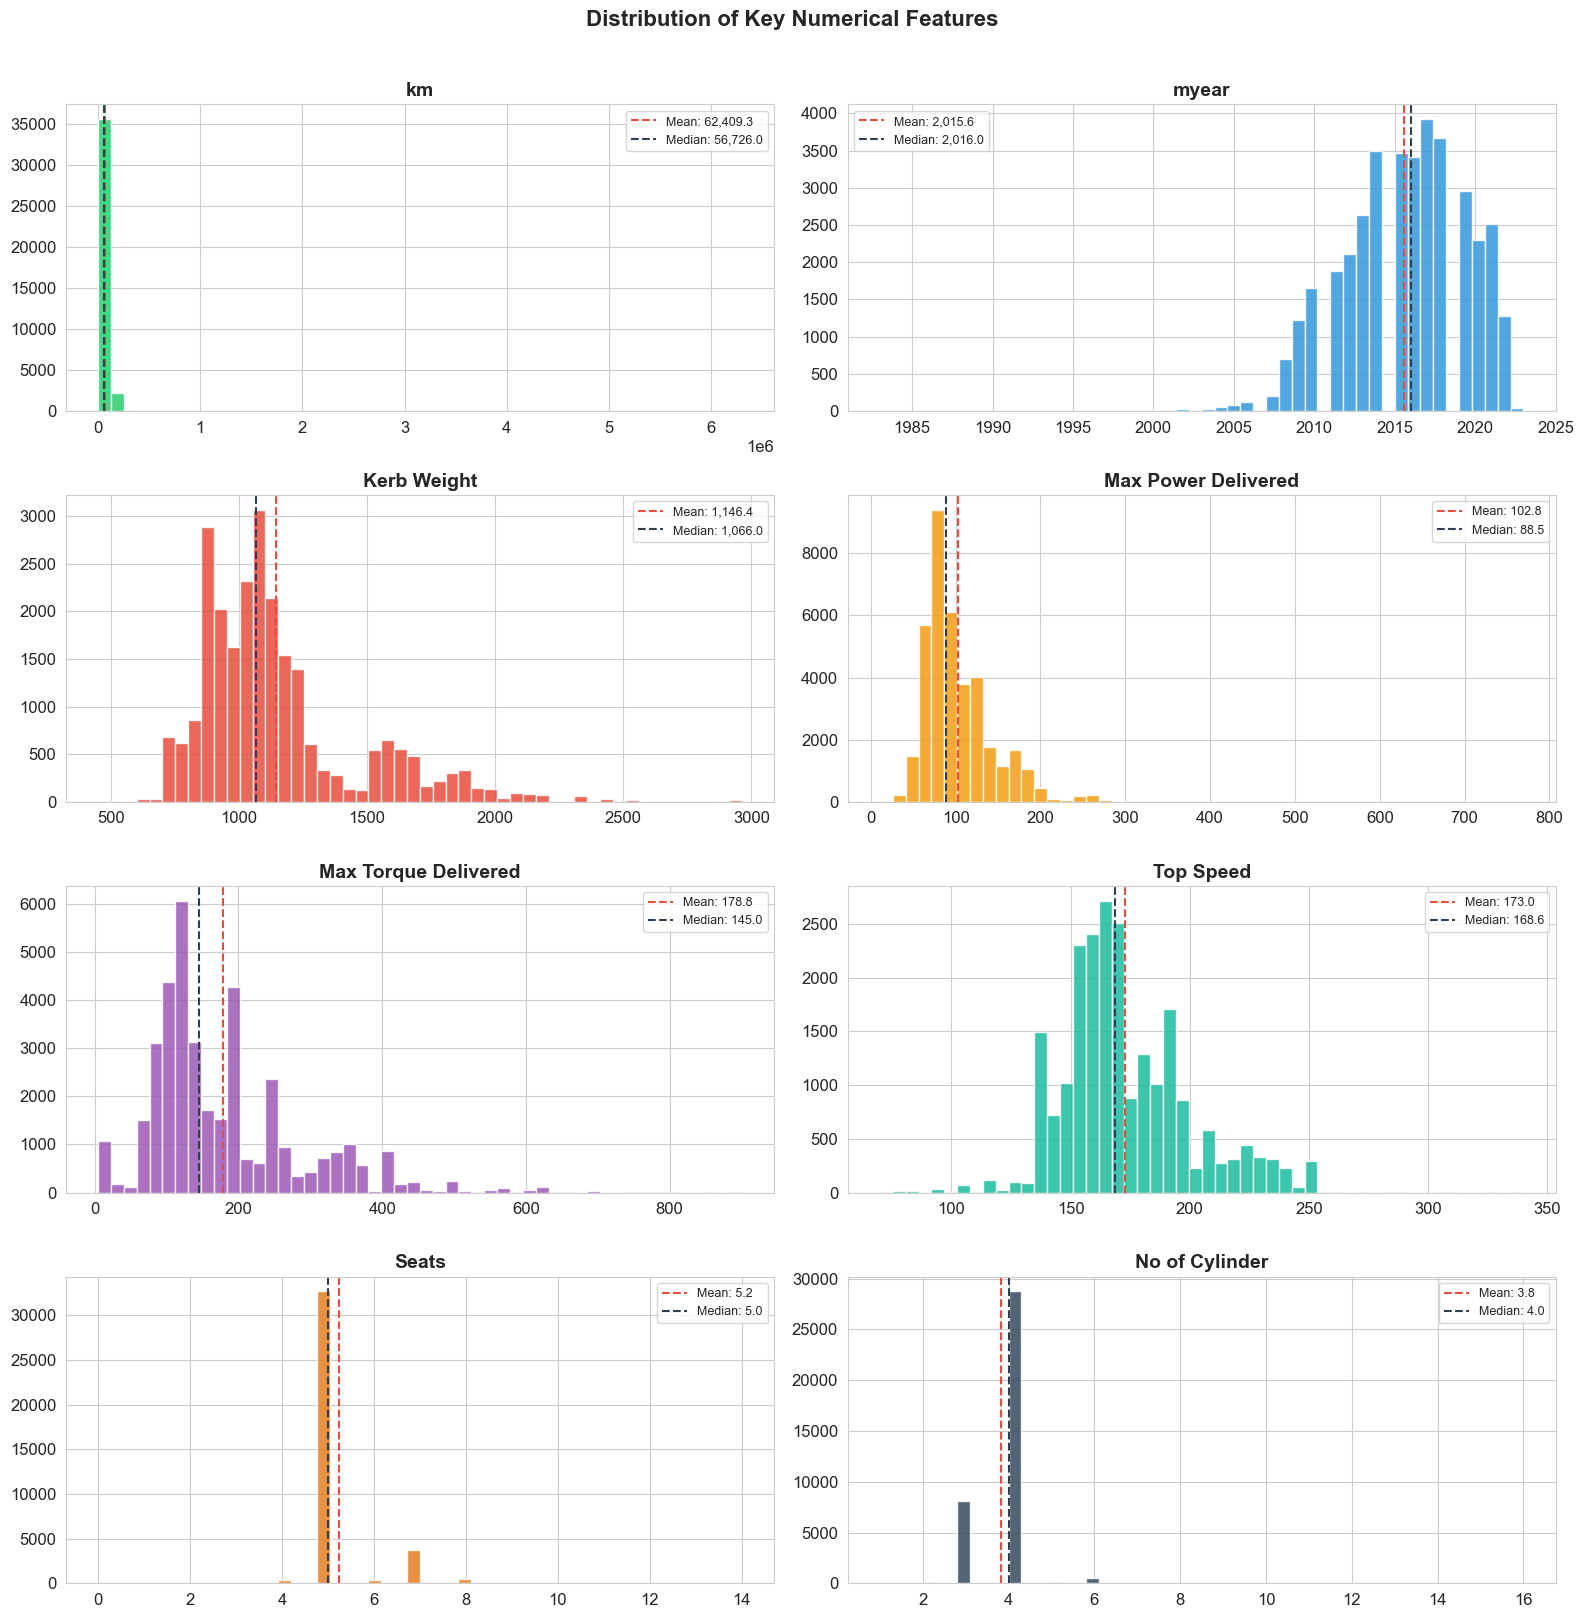

In [9]:
# ── Distribution of key numerical features ──
#
# We pick the most important ones to visualize.

key_num_features = ['km', 'myear', 'Kerb Weight', 'Max Power Delivered',
                    'Max Torque Delivered', 'Top Speed', 'Seats', 'No of Cylinder']
key_num_features = [c for c in key_num_features if c in df.columns]

n_features = len(key_num_features)
n_cols_plot = 2
n_rows_plot = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color=COLORS[i % len(COLORS)], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():,.1f}')
    ax.axvline(data.median(), color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Median: {data.median():,.1f}')
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(fontsize=9)

# Hide any unused subplot
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

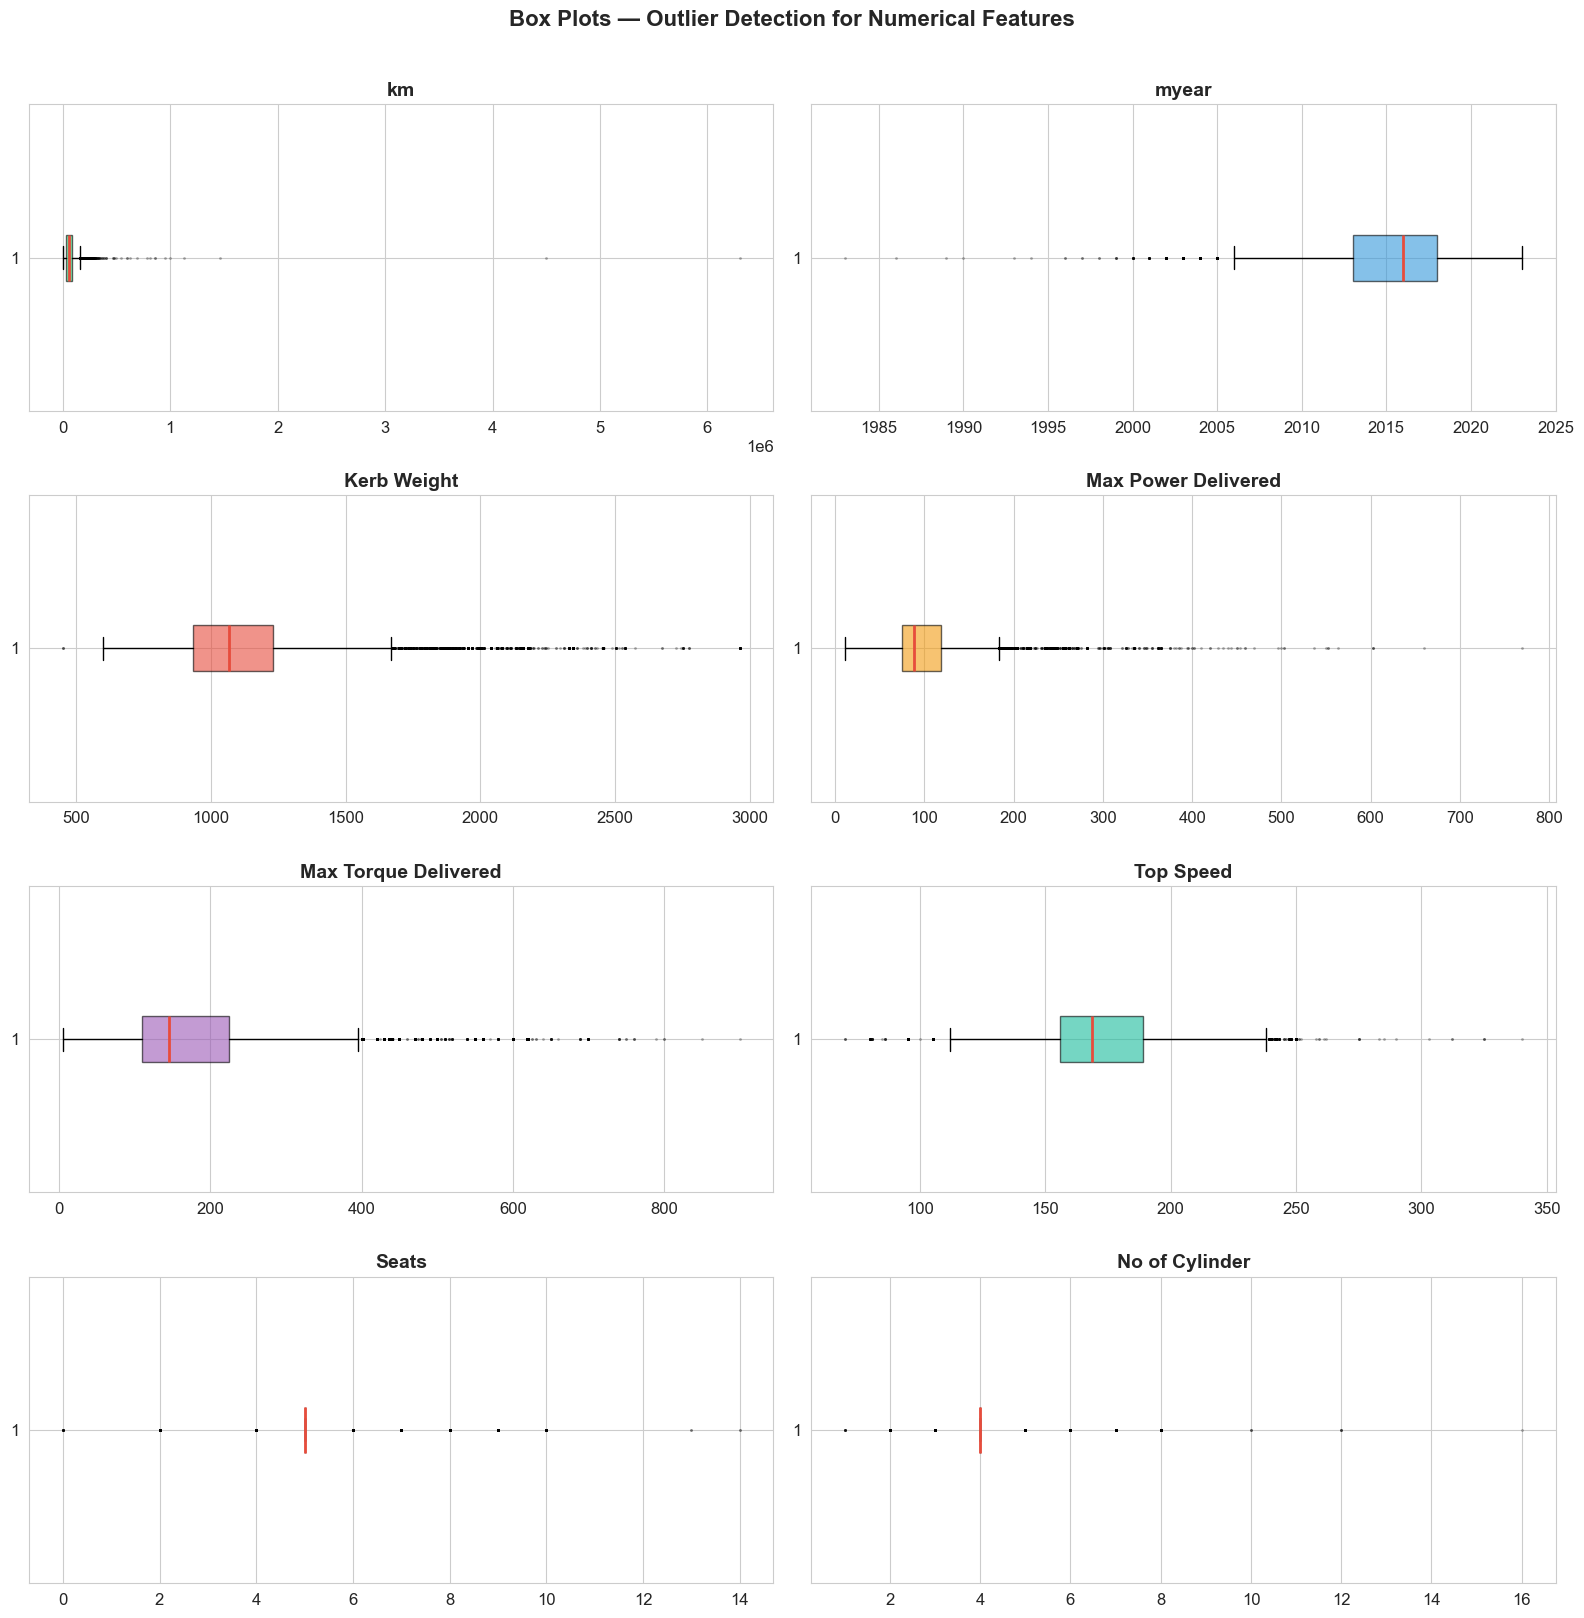

In [10]:
# ── Box plots for numerical features (to see outliers) ──

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    ax = axes[i]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(f'{col}', fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection for Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# ── Summary statistics for all numerical columns ──

print('📈 DESCRIPTIVE STATISTICS — Numerical Columns')
print('=' * 80)
df[num_cols].describe().T

📈 DESCRIPTIVE STATISTICS — Numerical Columns


,count,mean,std,min,25%,50%,75%,max
listed_price,"37,813.00","799,986.81","3,043,044.88","11,963.00","320,000.00","525,000.00","855,272.00","550,000,555.00"
km,"37,813.00","62,409.30","58,472.16",101.00,"31,739.00","56,726.00","83,310.00","6,300,000.00"
myear,"37,813.00","2,015.57",3.78,"1,983.00","2,013.00","2,016.00","2,018.00","2,023.00"
imgCount,"37,813.00",15.57,8.36,0.00,10.00,15.00,21.00,74.00
discountValue,"37,813.00",73.28,"2,805.78",0.00,0.00,0.00,0.00,"200,000.00"
Length,"37,451.00","4,113.62",399.36,"2,752.00","3,795.00","3,995.00","4,440.00","5,982.00"
Width,"37,442.00","1,725.59",128.29,"1,312.00","1,680.00","1,710.00","1,790.00","2,236.00"
Height,"37,450.00","1,577.55",115.15,"1,165.00","1,495.00","1,530.00","1,642.00","2,075.00"
Wheel Base,"37,257.00","2,545.82",155.30,"1,840.00","2,425.00","2,520.00","2,647.00","3,772.00"
Kerb Weight,"24,674.00","1,146.36",318.52,451.00,935.00,"1,066.00","1,230.00","2,962.00"


---
## 4. Categorical Features Analysis 🏷️

Let's understand the categorical features — what values they take and how frequent each value is.

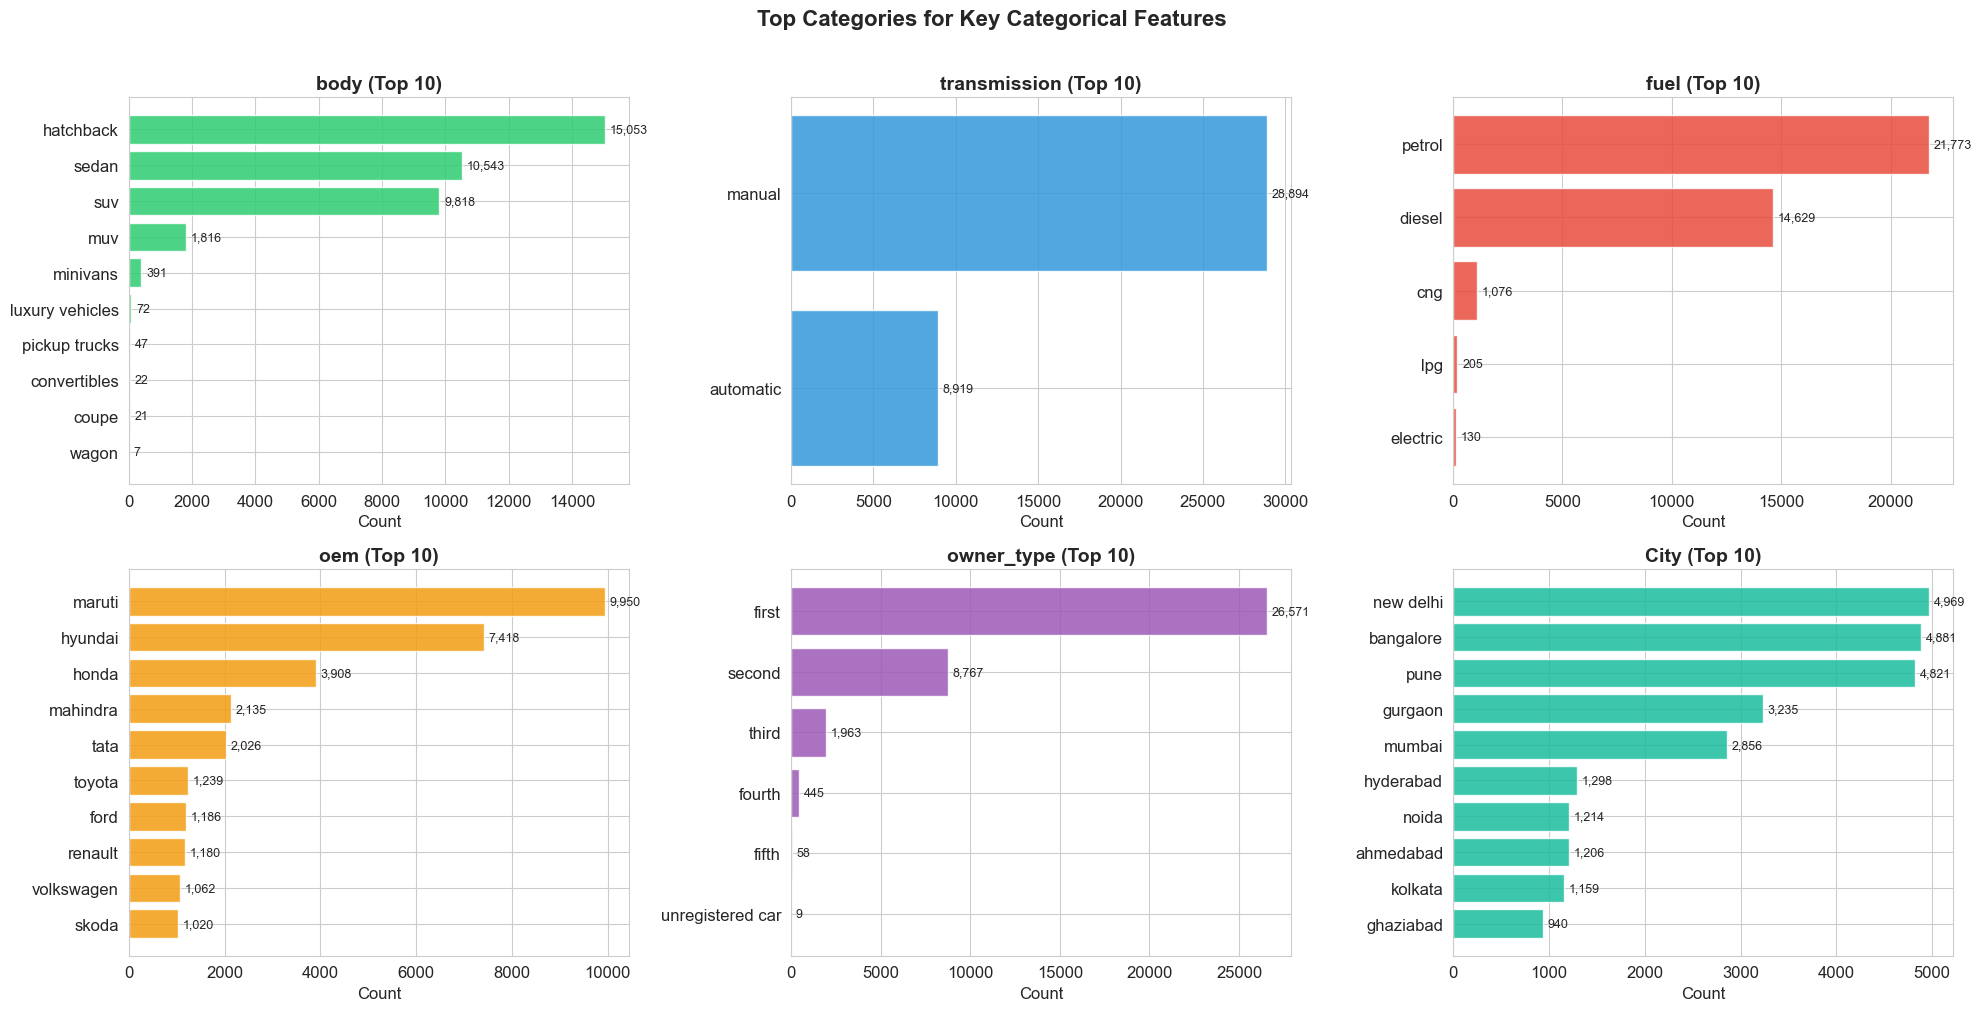

In [12]:
# ── Value counts for important categorical columns ──
#
# We'll look at the top categories for each feature.

key_cat_features = ['body', 'transmission', 'fuel', 'oem', 'owner_type', 'City']
key_cat_features = [c for c in key_cat_features if c in df.columns]

n_features = len(key_cat_features)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_cat_features):
    ax = axes[i]
    # Show top 10 categories only (to keep charts readable)
    top_vals = df[col].value_counts().head(10)
    bars = ax.barh(top_vals.index[::-1], top_vals.values[::-1],
                   color=COLORS[i % len(COLORS)], edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} (Top 10)', fontweight='bold')
    ax.set_xlabel('Count')
    
    # Add count labels
    for bar, val in zip(bars, top_vals.values[::-1]):
        ax.text(bar.get_width() + max(top_vals.values) * 0.01, bar.get_y() + bar.get_height()/2.,
                f'{val:,}', ha='left', va='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Categories for Key Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── Unique value counts per categorical column ──

cat_summary = pd.DataFrame({
    'Column': cat_cols,
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Most Common': [df[c].mode().iloc[0] if not df[c].mode().empty else 'N/A' for c in cat_cols],
    'Most Common Count': [df[c].value_counts().iloc[0] if df[c].notna().any() else 0 for c in cat_cols],
    'Missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('Unique Values', ascending=False).reset_index(drop=True)
cat_summary.index += 1
cat_summary.index.name = '#'

print('🏷️  CATEGORICAL COLUMNS OVERVIEW')
cat_summary

🏷️  CATEGORICAL COLUMNS OVERVIEW


,Column,Unique Values,Most Common,Most Common Count,Missing
#,,,,,
1,Color,747,white,10059,160
2,exterior_color,747,white,10067,123
3,City,617,new delhi,4969,0
4,model,382,honda city,1911,0
5,oem,46,maruti,9950,0
6,state,33,maharashtra,8628,0
7,Fuel Suppy System,14,Multi-Point Fuel Injection,14055,5502
8,Gear Box,11,5 speed,25203,471
9,body,11,hatchback,15053,19


---
## 5. Feature vs Target Relationships 📈

This is the **most important section** — we'll see how each feature relates to the car's `listed_price`.  
This helps us understand **what factors drive the price up or down**.

### 5.1 Numerical Features vs Price

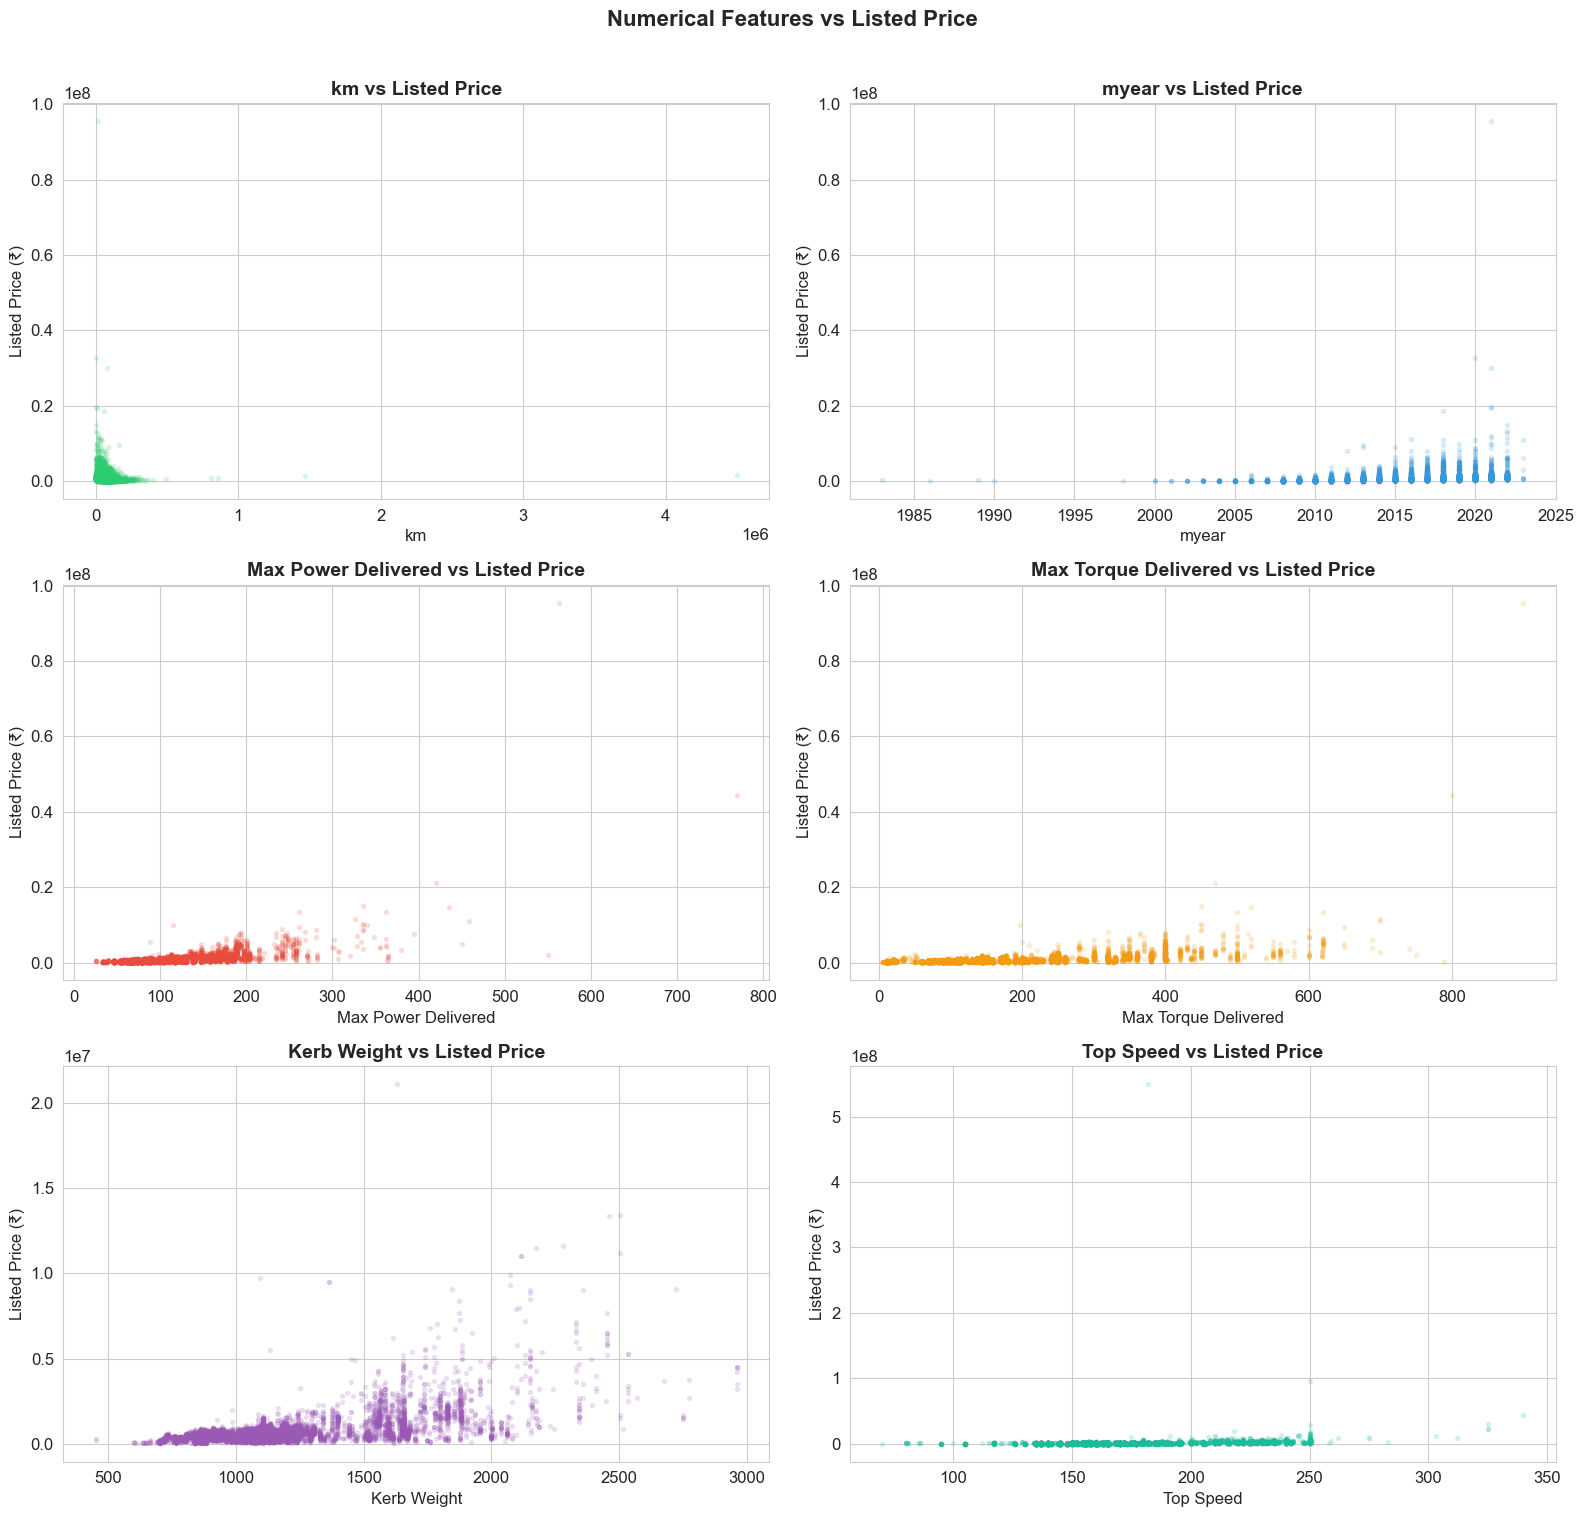

💡 Key patterns to look for:
   • km vs price: Higher km (more used) → generally lower price
   • myear vs price: Newer cars (higher year) → generally higher price
   • Max Power vs price: More powerful cars tend to cost more


In [14]:
# ── Scatter plots: Numerical features vs listed_price ──
#
# Each dot is a car. We're looking for patterns:
#   - Upward trend = higher feature value → higher price
#   - Downward trend = higher feature value → lower price
#   - No trend = feature doesn't strongly affect price

scatter_features = ['km', 'myear', 'Max Power Delivered', 'Max Torque Delivered',
                    'Kerb Weight', 'Top Speed']
scatter_features = [c for c in scatter_features if c in df.columns]

n_sf = len(scatter_features)
n_cols_p = 2
n_rows_p = (n_sf + 1) // 2

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 5 * n_rows_p))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    ax = axes[i]
    # Sample for performance (scatter with 100k+ points is slow)
    sample = df[[col, 'listed_price']].dropna()
    if len(sample) > 10000:
        sample = sample.sample(10000, random_state=42)
    
    ax.scatter(sample[col], sample['listed_price'],
               alpha=0.15, s=8, color=COLORS[i % len(COLORS)])
    ax.set_title(f'{col} vs Listed Price', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Listed Price (₹)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Listed Price', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Key patterns to look for:')
print('   • km vs price: Higher km (more used) → generally lower price')
print('   • myear vs price: Newer cars (higher year) → generally higher price')
print('   • Max Power vs price: More powerful cars tend to cost more')

### 5.2 Categorical Features vs Price

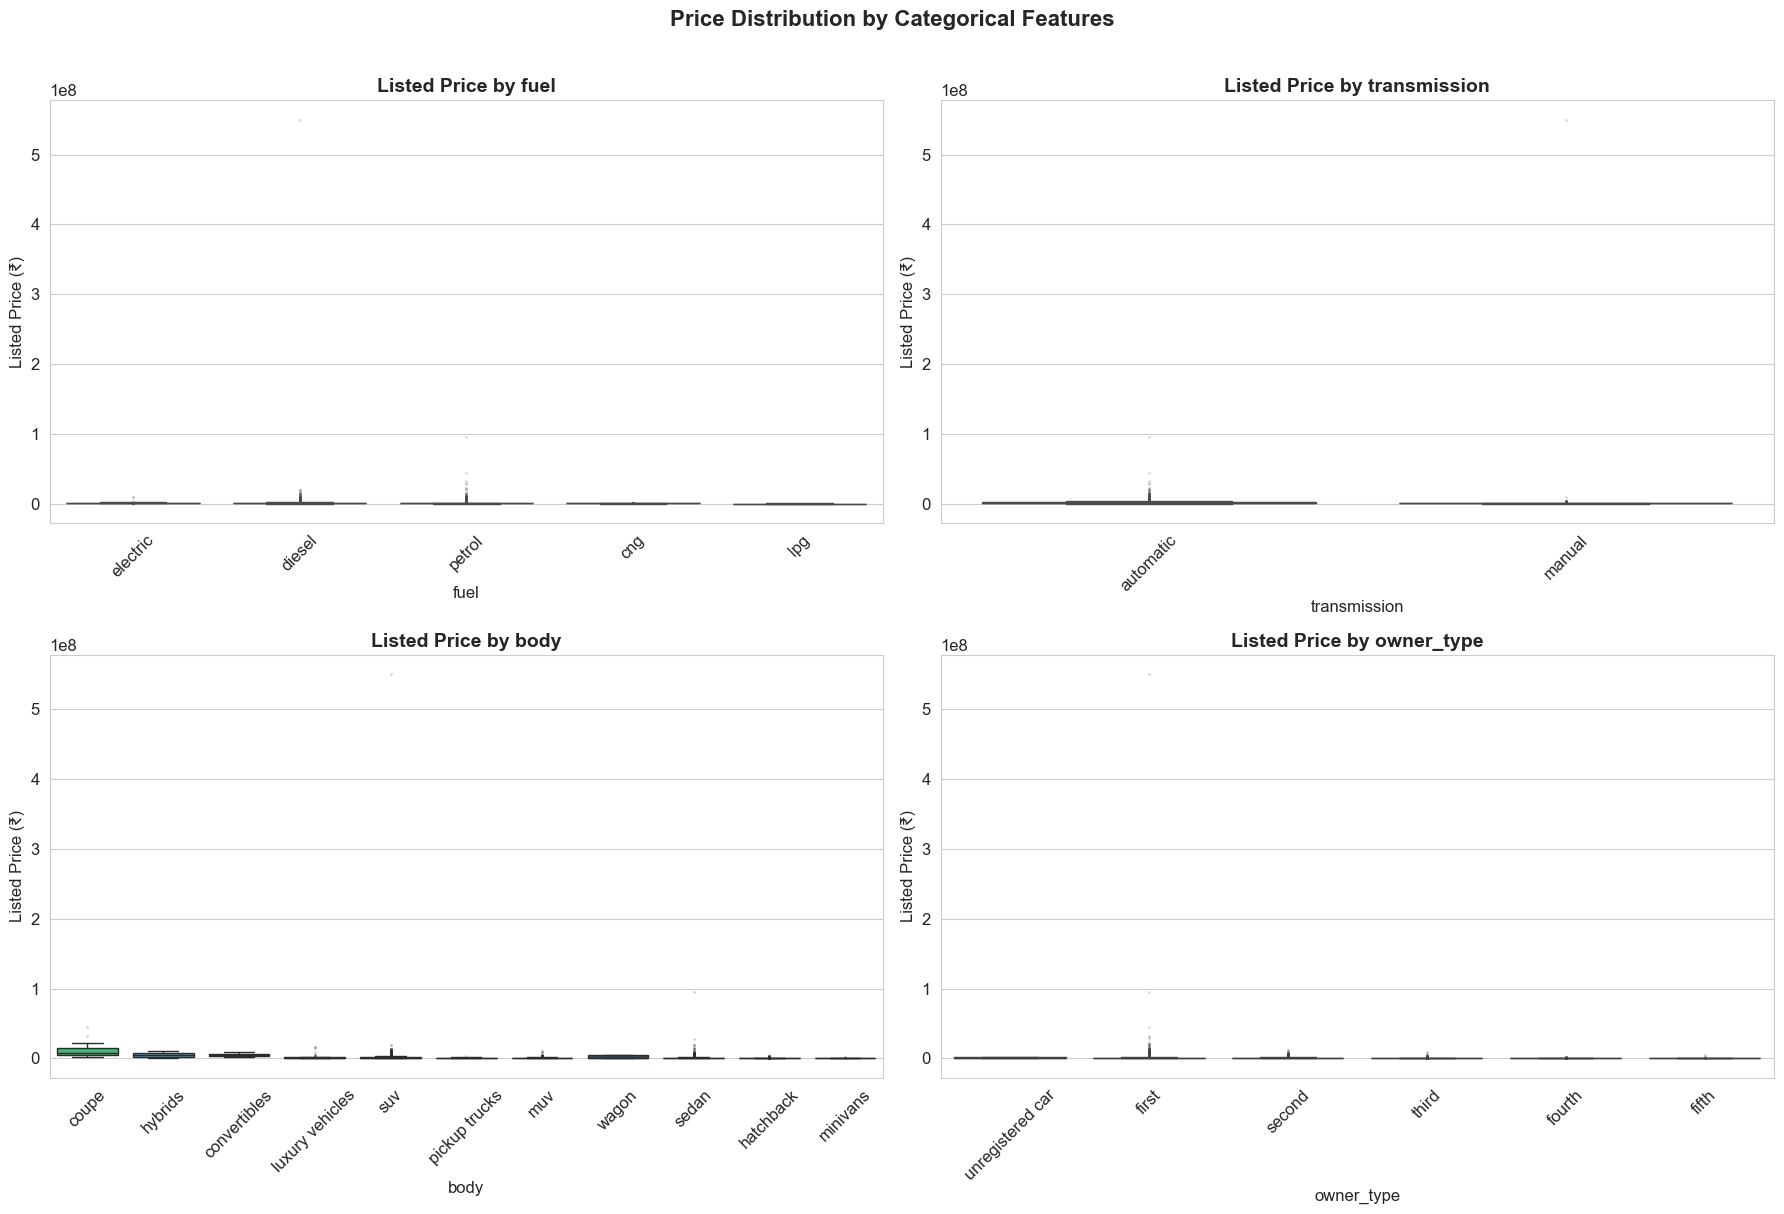

In [15]:
# ── Box plots: Price distribution by key categories ──
#
# These show how price varies across different categories.
# The box shows the middle 50% of prices; the line inside is the median.

cat_vs_price = ['fuel', 'transmission', 'body', 'owner_type']
cat_vs_price = [c for c in cat_vs_price if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_vs_price):
    ax = axes[i]
    # Order by median price (descending)
    order = df.groupby(col)['listed_price'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x=col, y='listed_price', order=order, ax=ax,
                palette=COLORS, fliersize=1, flierprops=dict(alpha=0.2))
    ax.set_title(f'Listed Price by {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Listed Price (₹)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Price Distribution by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

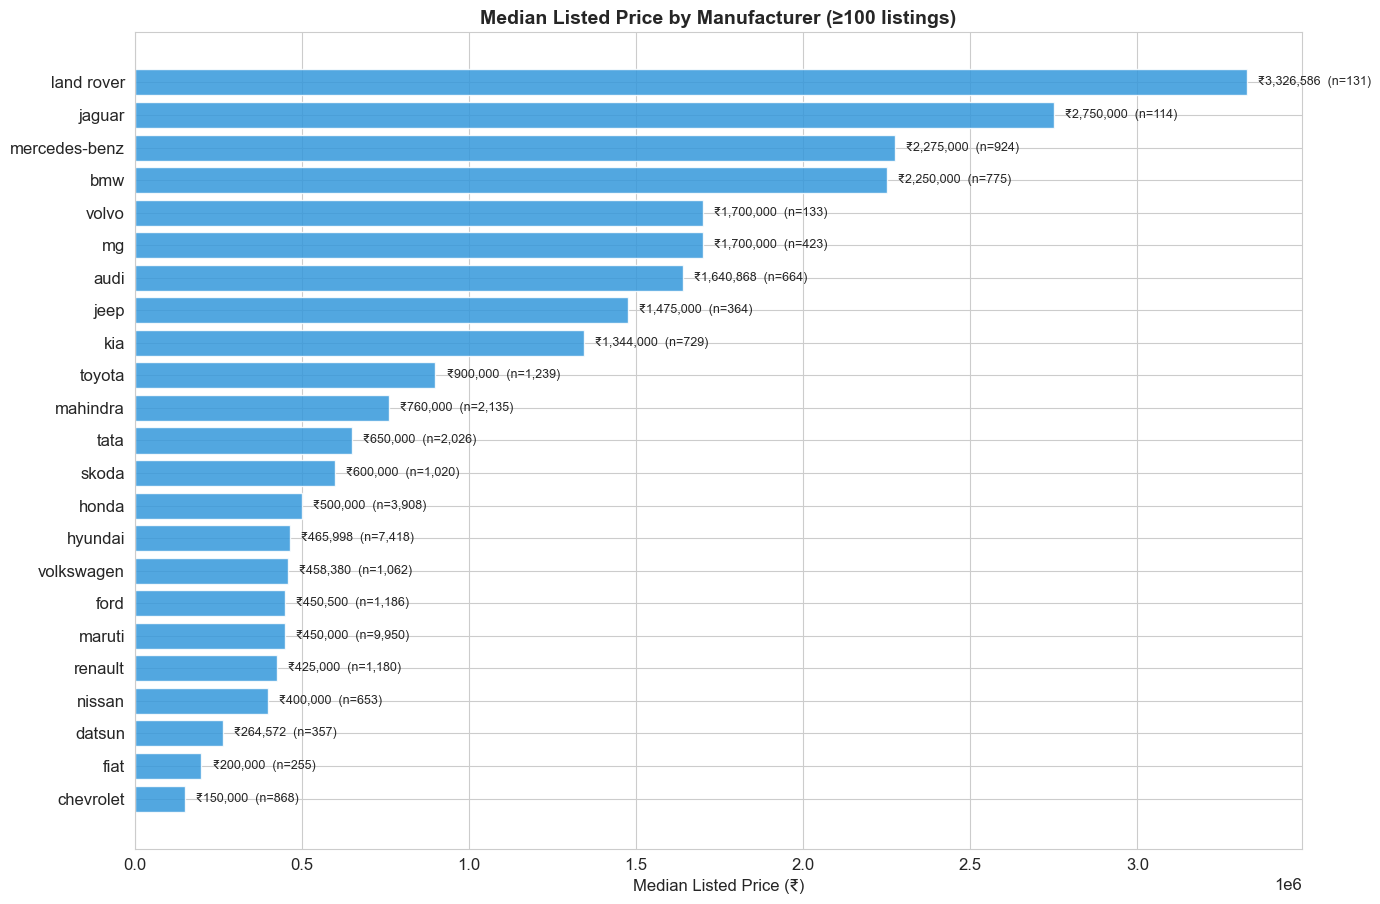

💡 Insight: Premium brands (like BMW, Audi, Mercedes) are clearly separated from budget brands.


In [16]:
# ── Median price by top car manufacturers (OEM) ──

if 'oem' in df.columns:
    oem_price = df.groupby('oem')['listed_price'].agg(['median', 'count']).reset_index()
    oem_price.columns = ['OEM', 'Median Price', 'Count']
    
    # Filter: at least 100 cars for reliable stats
    oem_price = oem_price[oem_price['Count'] >= 100].sort_values('Median Price', ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(oem_price) * 0.4)))
    bars = ax.barh(oem_price['OEM'], oem_price['Median Price'],
                   color=COLORS[1], edgecolor='white', alpha=0.85)
    
    for bar, price, count in zip(bars, oem_price['Median Price'], oem_price['Count']):
        ax.text(bar.get_width() + oem_price['Median Price'].max() * 0.01,
                bar.get_y() + bar.get_height()/2.,
                f'₹{price:,.0f}  (n={count:,})', ha='left', va='center', fontsize=9)
    
    ax.set_title('Median Listed Price by Manufacturer (≥100 listings)', fontweight='bold', fontsize=14)
    ax.set_xlabel('Median Listed Price (₹)')
    plt.tight_layout()
    plt.show()
    
    print('💡 Insight: Premium brands (like BMW, Audi, Mercedes) are clearly separated from budget brands.')

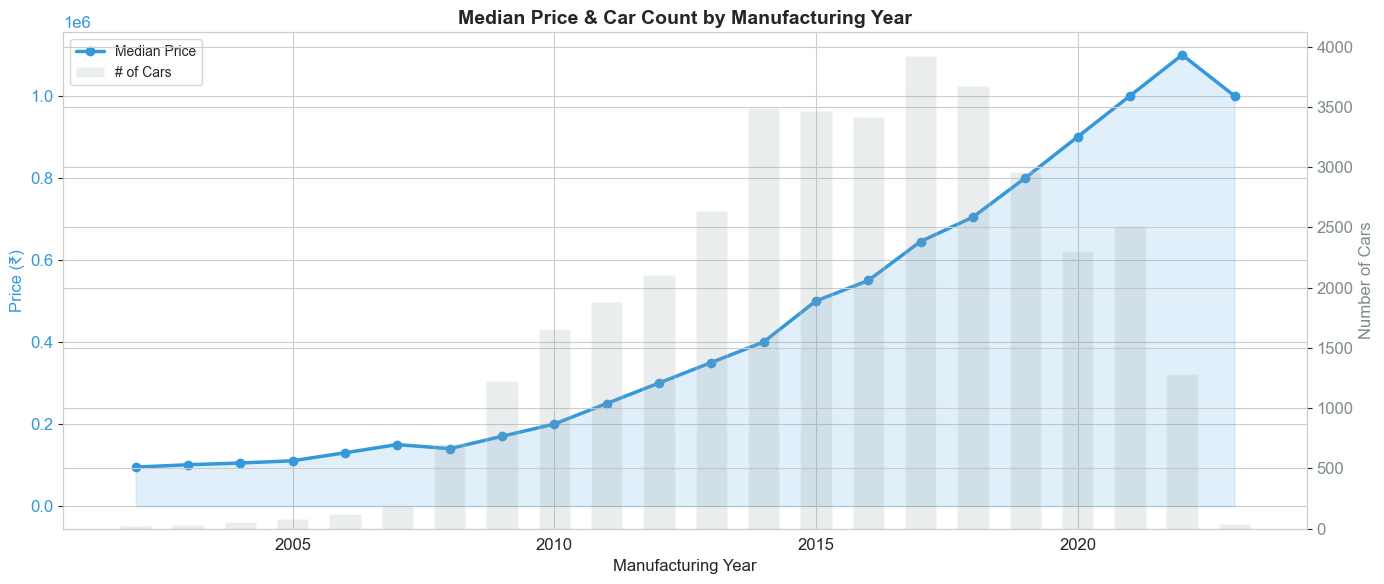

💡 Insight: Newer cars command higher prices — there is a clear upward trend with manufacturing year.


In [17]:
# ── Average price by manufacturing year ──

if 'myear' in df.columns:
    year_price = df.groupby('myear')['listed_price'].agg(['median', 'mean', 'count']).reset_index()
    year_price.columns = ['Year', 'Median Price', 'Mean Price', 'Count']
    
    # Filter to years with enough data
    year_price = year_price[year_price['Count'] >= 20]
    
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Line chart for median price
    ax1.plot(year_price['Year'], year_price['Median Price'],
             marker='o', color='#3498db', linewidth=2.5, markersize=6, label='Median Price', zorder=5)
    ax1.fill_between(year_price['Year'], year_price['Median Price'], alpha=0.15, color='#3498db')
    ax1.set_xlabel('Manufacturing Year')
    ax1.set_ylabel('Price (₹)', color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')
    
    # Bar chart for count (secondary axis)
    ax2 = ax1.twinx()
    ax2.bar(year_price['Year'], year_price['Count'],
            alpha=0.2, color='#95a5a6', label='# of Cars', width=0.6)
    ax2.set_ylabel('Number of Cars', color='#7f8c8d')
    ax2.tick_params(axis='y', labelcolor='#7f8c8d')
    
    ax1.set_title('Median Price & Car Count by Manufacturing Year', fontweight='bold', fontsize=14)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print('💡 Insight: Newer cars command higher prices — there is a clear upward trend with manufacturing year.')

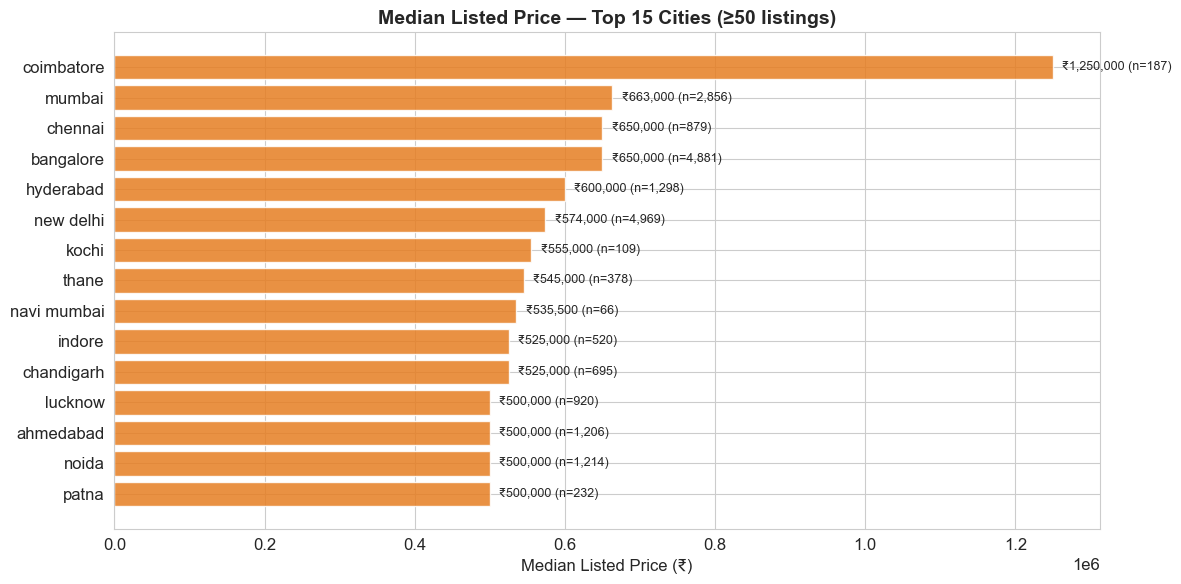

In [18]:
# ── Price by top 15 cities ──

if 'City' in df.columns:
    city_price = df.groupby('City')['listed_price'].agg(['median', 'count']).reset_index()
    city_price.columns = ['City', 'Median Price', 'Count']
    city_price = city_price[city_price['Count'] >= 50].sort_values('Median Price', ascending=True).tail(15)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(city_price['City'], city_price['Median Price'],
                   color='#e67e22', edgecolor='white', alpha=0.85)
    
    for bar, price, count in zip(bars, city_price['Median Price'], city_price['Count']):
        ax.text(bar.get_width() + city_price['Median Price'].max() * 0.01,
                bar.get_y() + bar.get_height()/2.,
                f'₹{price:,.0f} (n={count:,})', ha='left', va='center', fontsize=9)
    
    ax.set_title('Median Listed Price — Top 15 Cities (≥50 listings)', fontweight='bold', fontsize=14)
    ax.set_xlabel('Median Listed Price (₹)')
    plt.tight_layout()
    plt.show()

---
## 6. Correlation Analysis 📊

**Correlation** tells us how strongly two numerical features move together.  
- **+1** = Perfect positive correlation (both go up together)  
- **-1** = Perfect negative correlation (one goes up, other goes down)  
- **0** = No linear relationship

In [19]:
# ── Correlation with listed_price ──
#
# Let's see which numerical features are most correlated with price.

# Select only numerical columns that exist and have enough data
corr_cols = [c for c in num_cols if c in df.columns and df[c].notna().sum() > 1000]
price_corr = df[corr_cols].corr()['listed_price'].drop('listed_price').sort_values(ascending=False)

print('🔗 CORRELATION WITH LISTED PRICE')
print('=' * 55)
print(f'{"Feature":<30} {"Correlation":>12}  Strength')
print('-' * 55)
for feat, corr_val in price_corr.items():
    abs_corr = abs(corr_val)
    if abs_corr >= 0.7:
        strength = '🟢 Strong'
    elif abs_corr >= 0.4:
        strength = '🟡 Moderate'
    elif abs_corr >= 0.2:
        strength = '🟠 Weak'
    else:
        strength = '🔴 Very Weak'
    print(f'{feat:<30} {corr_val:>+12.4f}  {strength}')
print('=' * 55)

🔗 CORRELATION WITH LISTED PRICE
Feature                         Correlation  Strength
-------------------------------------------------------
Kerb Weight                         +0.4803  🟡 Moderate
Gross Weight                        +0.4512  🟡 Moderate
Max Power Delivered                 +0.2485  🟠 Weak
Max Torque Delivered                +0.2142  🟠 Weak
Alloy Wheel Size                    +0.2022  🟠 Weak
Wheel Base                          +0.1952  🔴 Very Weak
Width                               +0.1950  🔴 Very Weak
Top Speed                           +0.1725  🔴 Very Weak
Length                              +0.1681  🔴 Very Weak
No of Cylinder                      +0.1373  🔴 Very Weak
myear                               +0.1210  🔴 Very Weak
Cargo Volume                        +0.0901  🔴 Very Weak
Height                              +0.0593  🔴 Very Weak
Seats                               +0.0223  🔴 Very Weak
Valves per Cylinder                 +0.0195  🔴 Very Weak
Compression Ratio   

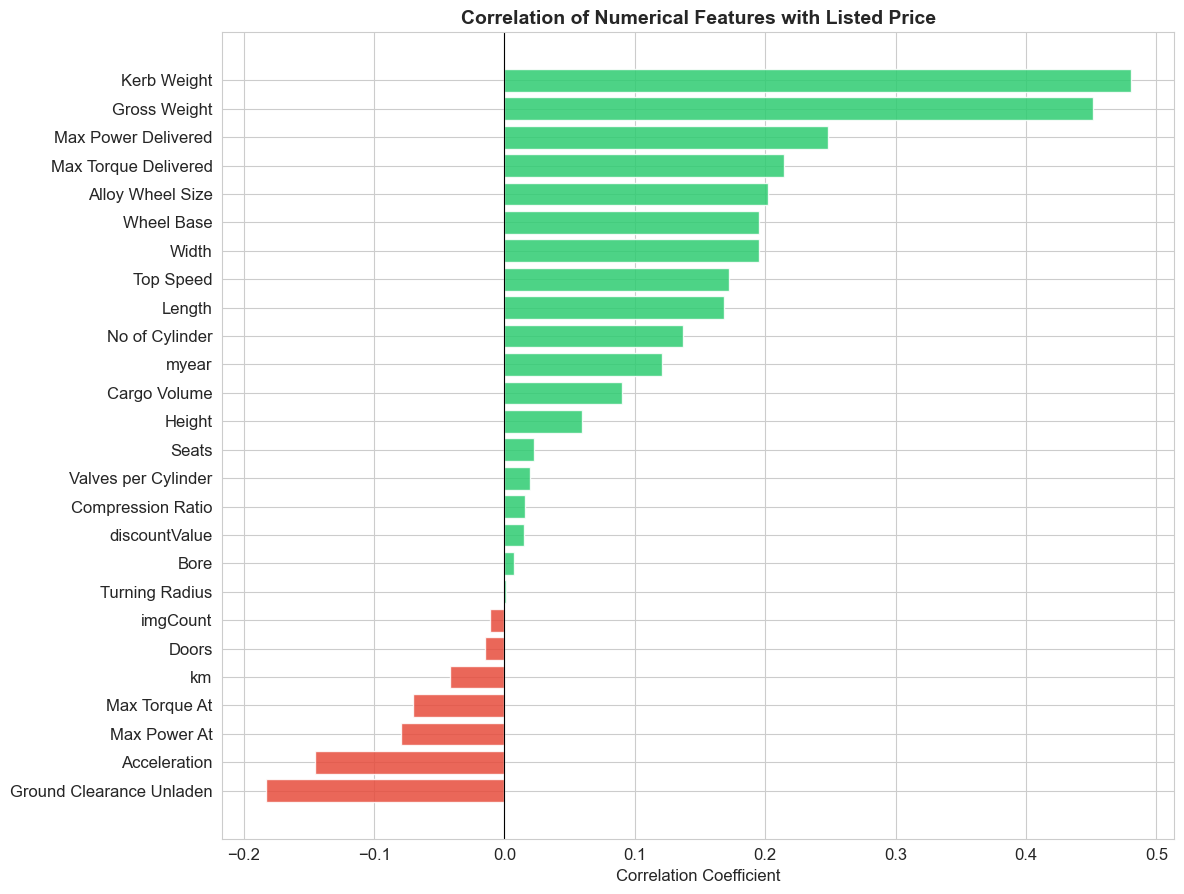

💡 Green = positive correlation (feature ↑ → price ↑)
   Red   = negative correlation (feature ↑ → price ↓)


In [20]:
# ── Bar chart of correlations ──

fig, ax = plt.subplots(figsize=(12, max(6, len(price_corr) * 0.35)))

colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in price_corr.sort_values().values]
ax.barh(price_corr.sort_values().index, price_corr.sort_values().values,
        color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numerical Features with Listed Price', fontweight='bold', fontsize=14)
ax.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

print('💡 Green = positive correlation (feature ↑ → price ↑)')
print('   Red   = negative correlation (feature ↑ → price ↓)')

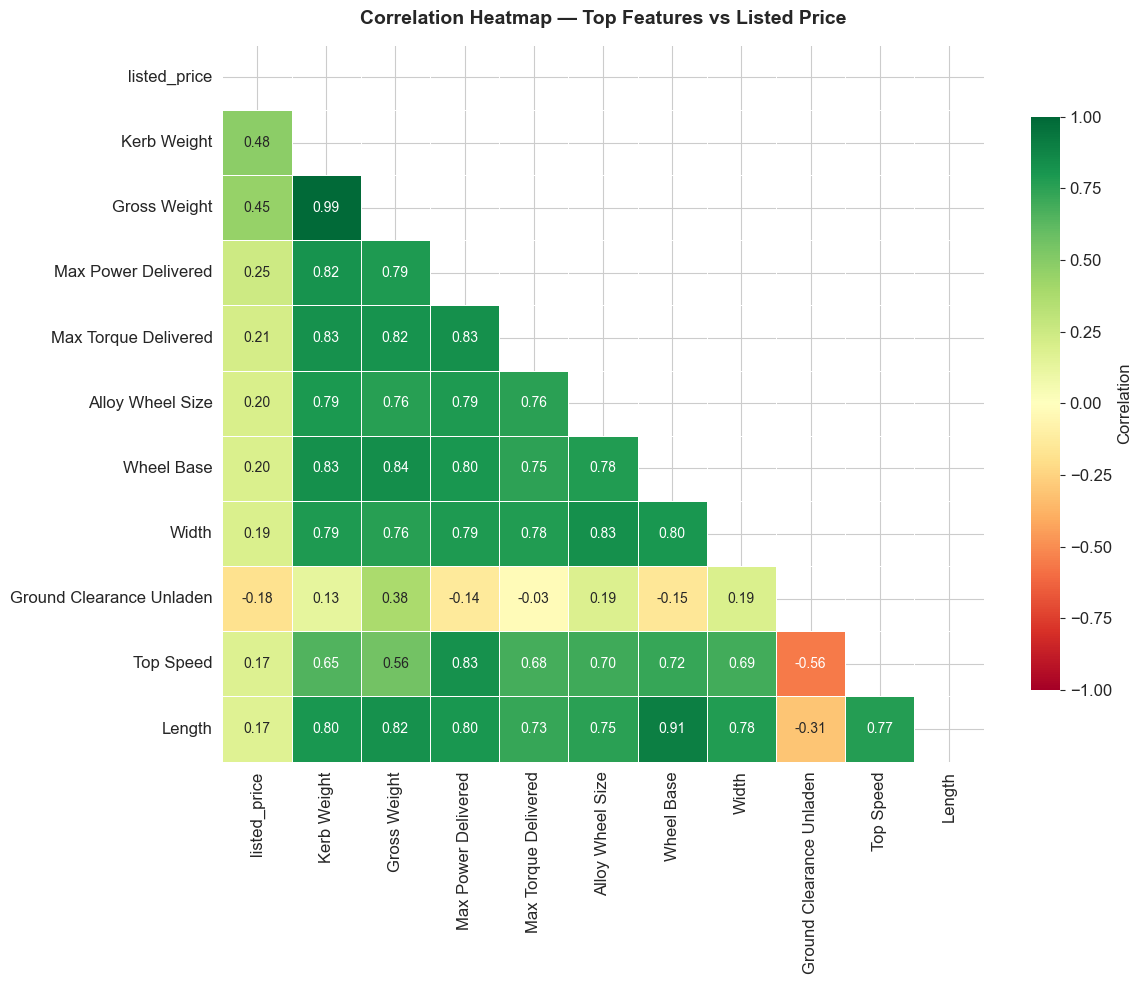

💡 Look for:
   • Dark green = strong positive correlation
   • Dark red   = strong negative correlation
   • White/yellow = weak or no correlation
   • High correlation between two features (not price) means they are redundant — we may drop one later.


In [21]:
# ── Correlation Heatmap (top correlated features only) ──
#
# A heatmap shows correlations BETWEEN features too.
# We pick the top features to keep it readable.

top_corr_features = price_corr.abs().sort_values(ascending=False).head(10).index.tolist()
top_corr_features = ['listed_price'] + top_corr_features

corr_matrix = df[top_corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Correlation Heatmap — Top Features vs Listed Price', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print('💡 Look for:')
print('   • Dark green = strong positive correlation')
print('   • Dark red   = strong negative correlation')
print('   • White/yellow = weak or no correlation')
print('   • High correlation between two features (not price) means they are redundant — we may drop one later.')

---
## 7. Key Insights & Takeaways 📌

Run all cells above, then review the findings below.

In [22]:
# ── Auto-generated summary ──

print('=' * 70)
print('📌 EDA SUMMARY — KEY INSIGHTS')
print('=' * 70)

# 1. Target
print(f'\n🎯 TARGET VARIABLE (listed_price):')
print(f'   • Range: ₹{target.min():,.0f} — ₹{target.max():,.0f}')
print(f'   • Median: ₹{target.median():,.0f}  |  Mean: ₹{target.mean():,.0f}')
print(f'   • Skewness: {target.skew():.2f} → heavily right-skewed')
print(f'   • Consider using log-transform for modeling')

# 2. Top correlated features
print(f'\n🔗 TOP 5 FEATURES CORRELATED WITH PRICE:')
for i, (feat, val) in enumerate(price_corr.head(5).items(), 1):
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'   {i}. {feat}: {val:+.4f} ({direction})')

# 3. Bottom correlated (negative)
print(f'\n🔻 TOP NEGATIVELY CORRELATED FEATURES:')
for i, (feat, val) in enumerate(price_corr.tail(3).items(), 1):
    print(f'   {i}. {feat}: {val:+.4f}')

# 4. Categorical insights
print(f'\n🏷️  CATEGORICAL INSIGHTS:')
if 'fuel' in df.columns:
    top_fuel = df.groupby('fuel')['listed_price'].median().sort_values(ascending=False)
    print(f'   • Highest median price by fuel type: {top_fuel.index[0]} (₹{top_fuel.iloc[0]:,.0f})')
if 'transmission' in df.columns:
    top_trans = df.groupby('transmission')['listed_price'].median().sort_values(ascending=False)
    print(f'   • Highest median price by transmission: {top_trans.index[0]} (₹{top_trans.iloc[0]:,.0f})')
if 'body' in df.columns:
    top_body = df.groupby('body')['listed_price'].median().sort_values(ascending=False)
    print(f'   • Highest median price by body type: {top_body.index[0]} (₹{top_body.iloc[0]:,.0f})')

# 5. Data quality
total_missing = df.isnull().sum().sum()
total_cells = df.size
print(f'\n⚠️  DATA QUALITY:')
print(f'   • Overall missing: {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.1f}%)')
high_miss = df.isnull().mean().sort_values(ascending=False)
high_miss = high_miss[high_miss > 0.3]
if len(high_miss) > 0:
    print(f'   • Columns with >30% missing: {list(high_miss.index)}')

print(f'\n' + '=' * 70)
print('✅ EDA Complete! Next steps: Data Preprocessing & Feature Engineering')
print('=' * 70)

📌 EDA SUMMARY — KEY INSIGHTS

🎯 TARGET VARIABLE (listed_price):
   • Range: ₹11,963 — ₹550,000,555
   • Median: ₹525,000  |  Mean: ₹799,987
   • Skewness: 156.62 → heavily right-skewed
   • Consider using log-transform for modeling

🔗 TOP 5 FEATURES CORRELATED WITH PRICE:
   1. Kerb Weight: +0.4803 (↑ positive)
   2. Gross Weight: +0.4512 (↑ positive)
   3. Max Power Delivered: +0.2485 (↑ positive)
   4. Max Torque Delivered: +0.2142 (↑ positive)
   5. Alloy Wheel Size: +0.2022 (↑ positive)

🔻 TOP NEGATIVELY CORRELATED FEATURES:
   1. Max Power At: -0.0795
   2. Acceleration: -0.1455
   3. Ground Clearance Unladen: -0.1832

🏷️  CATEGORICAL INSIGHTS:
   • Highest median price by fuel type: electric (₹1,465,000)
   • Highest median price by transmission: automatic (₹1,125,000)
   • Highest median price by body type: coupe (₹7,000,000)

⚠️  DATA QUALITY:
   • Overall missing: 282,038 / 2,533,471 (11.1%)
   • Columns with >30% missing: ['Stroke', 'Ground Clearance Unladen', 'Compression Ra

In [23]:
# Clean up temporary column
df.drop(columns=['price_segment'], inplace=True, errors='ignore')